# Task 2.1 Notebook 1: Data and differential expression (GSE75214)

**Goal.** Find genes whose expression is different between IBD (disease) and control.
This step follows the statistics pipeline reviewed by Rosati et al. (2024).

**Input.** `01_Data/gse75214_clean.csv` and the GPL6244 probe-to-gene map.
**Output.** DEG tables, a DEG matrix for Notebook 2, and figures.

GSE75214 is microarray data (already processed expression values). For this reason we use
**limma**, not edgeR or DESeq2. Those tools are made for RNA-seq counts.


## Key terms used in this notebook

| Term | Simple explanation |
| ---- | ------------------ |
| Probe | A small sequence on the microarray that measures one transcript. Several probes can map to the same gene. |
| Gene symbol | The usual gene name (for example SLC6A14). We collapse probes to this name. |
| Expression value | How strongly a gene is measured in a sample. Here the values are already log2-like intensities. |
| log2 transformation | A common scale for expression. A change of +1 means about a 2-fold increase. |
| DGE | Differential gene expression: testing which genes differ between two groups. |
| DEG | A gene that passes our statistical cutoffs. |
| logFC / log2FC | Size and direction of the change. Positive = higher in disease. Negative = lower in disease. |
| p-value | Chance of seeing a result this strong if there is no real difference. |
| FDR / adjusted p-value | p-value after correcting for thousands of tests. We use this to call DEGs. |
| empirical Bayes | limma shrinks gene variances toward a shared value so small studies are more stable. |
| Upregulated | logFC > 0: higher expression in disease. This is not automatically "good". |
| Downregulated | logFC < 0: lower expression in disease. This is not automatically "bad". |
| Volcano plot | x = logFC, y = statistical evidence. Right = up, left = down, high = small FDR. |
| MA plot | Average expression vs logFC. Checks that DEGs are not only low-expression genes. |
| Heatmap | Colour map of expression. Similar samples and similar genes are grouped by clustering. |

**Upregulated vs downregulated.** A candidate biomarker can be strongly up or strongly down.
Both directions can help separate disease and control.

**Why limma here?** The matrix has processed microarray values. edgeR and DESeq2 expect
raw RNA-seq counts and a Negative Binomial model. We do not turn microarray numbers into
fake counts.

| Method | Main idea | Typical data |
| ------ | --------- | ------------ |
| edgeR | Negative Binomial + TMM | RNA-seq counts |
| DESeq2 | Negative Binomial + size factors | RNA-seq counts |
| NOISeq | Noise / non-parametric | RNA-seq |
| SAMseq | Rank / resampling | sequencing data |
| limma | Linear models + empirical Bayes | microarray (this notebook) |

RNA-seq counts often vary more than a simple Poisson model expects. That extra variation
is called overdispersion. edgeR and DESeq2 use the Negative Binomial distribution to model
it. **Negative Binomial does not mean the outcome has only two classes.**

**TMM** (Trimmed Mean of M-values) is a library-size scaling method used with edgeR.
It is **not** applied to GSE75214 in this notebook.

```text
Raw RNA-seq counts
        ↓
Different library sizes
        ↓
TMM scaling factors
        ↓
More comparable samples
        ↓
DGE (edgeR)
```


## 1. Setup and load the data

In [1]:
# We import the shared functions and load the GSE75214 expression matrix.
# Rows are samples and columns are probes, with the binary target in the first column.
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sys.path.insert(0, str(pathlib.Path.cwd()))
import task2_1_lib as lib

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

DATA = pathlib.Path("../01_Data")
OUT = pathlib.Path("../04_Analysis")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA / "gse75214_clean.csv", index_col=0)
target = df["target"].astype(int).values
expr = df.drop(columns=["target"])
expr.columns = [str(col) for col in expr.columns]

n_ibd = int((target == 1).sum())
n_ctrl = int((target == 0).sum())
print("Samples by probes:", expr.shape)
print("Disease (1):", n_ibd, " Control (0):", n_ctrl)
print("Value range:", round(expr.values.min(), 2), "to", round(expr.values.max(), 2))


Samples by probes: (194, 33252)
Disease (1): 172  Control (0): 22
Value range: 2.03 to 14.58


## Dataset overview — skimr-style summary

Compact summaries follow the **skimr** idea ([ropensci/skimr](https://github.com/ropensci/skimr)).
Wide expression matrices use a compact fallback instead of printing every column.


Original matrix orientation: samples × probes
Original dimensions: 194 samples × 33,252 probes
Disease: 172   Control: 22
Missing cells: 0
GSE75214 probes (samples × probes)


,dataset,orientation,n_samples,n_features,missing_cells,missing_pct,inf_cells,min,q1,median,mean,q3,max,sd,zero_var_features,duplicate_feature_names,duplicate_sample_index,Disease,Control
0,GSE75214 probes,samples × features,194,33252,0,0.0,0,2.029953,5.215099,6.619168,6.741422,8.088335,14.580244,2.035337,0,0,0,172,22


Wide matrix (194 rows × 33252 cols): compact skimr-style summary (full per-column skimr not shown).


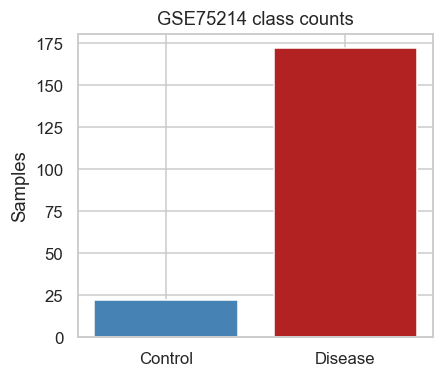

In [2]:
from task2_1_lib import skim_summary

print("Original matrix orientation: samples × probes")
print(f"Original dimensions: {expr.shape[0]} samples × {expr.shape[1]:,} probes")
print(f"Disease: {n_ibd}   Control: {n_ctrl}")
print(f"Missing cells: {int(np.isnan(expr.to_numpy()).sum())}")
skim_summary(
    expr, title="GSE75214 probes (samples × probes)",
    name="GSE75214 probes", y=target, class_names={1: "Disease", 0: "Control"},
)

fig, ax = plt.subplots(figsize=(4.2, 3.6))
ax.bar(["Control", "Disease"], [n_ctrl, n_ibd], color=["steelblue", "firebrick"])
ax.set_ylabel("Samples")
ax.set_title("GSE75214 class counts")
fig.tight_layout()
fig.savefig(FIG / "task2_1_class_counts.png", dpi=150)
plt.show()


GSE75214 has many more disease samples than controls. The values already look
like log2 microarray intensities (about 2 to 15), so we do not treat them as RNA-seq counts.
The bar plot is only a sample-size picture, not a biomarker result.


## 2. Collapse probes to genes

In [3]:
# Map each probe to a gene symbol with GPL6244, then keep the highest-mean probe per gene.
probe_map = pd.read_csv(DATA / "gpl6244_probe_to_symbol.csv")
probe_map["ID"] = probe_map["ID"].astype(str)

genes = lib.collapse_probes_to_genes(expr, probe_map)
print("After probe → gene mapping, orientation: samples × unique genes")
print(f"Gene-level matrix: {genes.shape[0]} samples × {genes.shape[1]:,} genes")
print("Example genes:", list(genes.columns[:8]))

skim_summary(
    genes, title="GSE75214 genes (samples × genes)",
    name="GSE75214 genes", y=target, class_names={1: "Disease", 0: "Control"},
)


After probe → gene mapping, orientation: samples × unique genes
Gene-level matrix: 194 samples × 21,147 genes
Example genes: ['1060P11.3', 'A1BG', 'A1CF', 'A2M', 'A2ML1', 'A3GALT2', 'A4GALT', 'A4GNT']
GSE75214 genes (samples × genes)


,dataset,orientation,n_samples,n_features,missing_cells,missing_pct,inf_cells,min,q1,median,mean,q3,max,sd,zero_var_features,duplicate_feature_names,duplicate_sample_index,Disease,Control
0,GSE75214 genes,samples × features,194,21147,0,0.0,0,2.427703,5.955665,7.167353,7.225239,8.358059,14.312401,1.710796,0,0,0,172,22


Wide matrix (194 rows × 21147 cols): compact skimr-style summary (full per-column skimr not shown).


,dataset,orientation,n_samples,n_features,missing_cells,missing_pct,inf_cells,min,q1,median,mean,q3,max,sd,zero_var_features,duplicate_feature_names,duplicate_sample_index,Disease,Control
0,GSE75214 genes,samples × features,194,21147,0,0.0,0,2.427703,5.955665,7.167353,7.225239,8.358059,14.312401,1.710796,0,0,0,172,22


Probes collapse to unique gene symbols. Working at gene level makes results
easier to compare with papers. A limitation: collapsing probes can hide transcript variants.


## 3. A quick look at the classes

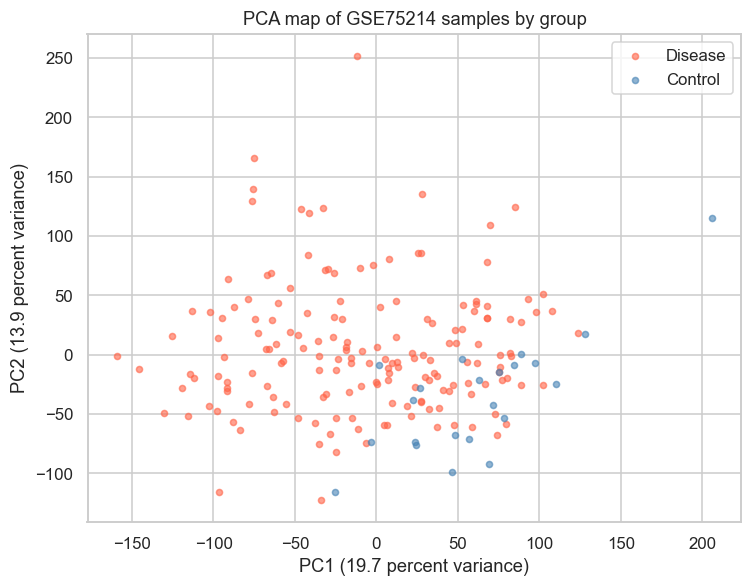

PC1 variance: 19.7 percent


In [4]:
# We reduce the genes to two PCA directions and colour the samples by group.
# This shows whether disease and control separate before any gene is tested.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaled = StandardScaler().fit_transform(genes.values)
pcs = PCA(n_components=2, random_state=42).fit_transform(scaled)
var = PCA(n_components=2, random_state=42).fit(scaled).explained_variance_ratio_

plt.figure(figsize=(7, 5.5))
for lab, name, color in [(1, "Disease", "tomato"), (0, "Control", "steelblue")]:
    m = target == lab
    plt.scatter(pcs[m, 0], pcs[m, 1], s=16, alpha=0.6, color=color, label=name)
plt.xlabel(f"PC1 ({var[0]*100:.1f} percent variance)")
plt.ylabel(f"PC2 ({var[1]*100:.1f} percent variance)")
plt.title("PCA map of GSE75214 samples by group")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "task2_1_pca.png", dpi=150)
plt.show()
print("PC1 variance:", round(var[0]*100, 1), "percent")

PCA is only a picture of major variation. If disease and control separate on
PC1, the groups look different in expression space. This is not a biomarker test and it is
not a VAE. A VAE would mix genes into latent axes that are harder to interpret, so we do
not use it here.


## 4. Differential expression with the limma moderated t test

In [5]:
# For every gene we compute the log2 fold change (disease mean minus control mean)
# and a moderated t test p value. The moderation borrows variance across genes so a
# gene with a tiny sample variance is not called significant by luck. We then convert
# p values to Benjamini Hochberg FDR. See task2_1_lib.limma_two_group.
dge, info = lib.limma_two_group(genes, target)
print("Empirical Bayes prior df d0:", round(info["d0"], 3))
print("Empirical Bayes prior variance s0^2:", round(info["s0_2"], 4))
print("Residual df per gene:", info["dg"])
print()
print("Strongest genes by moderated t:")
print(dge.reindex(dge["t_mod"].abs().sort_values(ascending=False).index)
        [["log2FC", "pval", "FDR", "direction"]].head(6).round(4).to_string())

Empirical Bayes prior df d0: 1.041
Empirical Bayes prior variance s0^2: 0.0797
Residual df per gene: 192

Strongest genes by moderated t:
              log2FC  pval  FDR direction
gene                                     
CNTFR        -1.9839   0.0  0.0      down
ST5           0.6189   0.0  0.0        up
FAM47E-STBD1 -1.2713   0.0  0.0      down
STBD1        -1.2713   0.0  0.0      down
LCN2          3.2448   0.0  0.0        up
PAQR5        -1.9605   0.0  0.0      down


limma uses empirical Bayes so genes with noisy variance share information.
This is helpful with 22 controls. The output is a logFC and an FDR for every gene. We still
need cutoffs (next section) before calling DEGs.


## 5. Call the differentially expressed genes

In [6]:
# A gene is a DEG when its FDR is below 0.05 and its absolute log2 fold change is at
# least 1, which means it at least doubles or halves between the groups. We also count
# the stricter cutoff of 1.5 because Task 2.2 uses that value.
from IPython.display import display

dge = lib.call_degs(dge, fdr_cut=0.05, fc_cut=1.0)
n_deg = int(dge["DEG"].sum())
n_up = int((dge["DEG"] & (dge["direction"] == "up")).sum())
n_down = int((dge["DEG"] & (dge["direction"] == "down")).sum())
n_15 = int(((dge["FDR"] < 0.05) & (dge["log2FC"].abs() >= 1.5)).sum())

print(f"DEGs at FDR < 0.05 and |log2FC| >= 1.0 : {n_deg}  (up {n_up}, down {n_down})")
print(f"DEGs at FDR < 0.05 and |log2FC| >= 1.5 : {n_15}")

up = dge[dge["DEG"] & (dge["direction"] == "up")].sort_values("log2FC", ascending=False)
down = dge[dge["DEG"] & (dge["direction"] == "down")].sort_values("log2FC")
cols = [c for c in ["log2FC", "FDR", "t", "AveExpr"] if c in dge.columns]
if not cols:
    cols = ["log2FC", "FDR"]

print(f"Total DEGs: {n_deg}")
print(f"Upregulated: {n_up}")
print(f"Downregulated: {n_down}")

def _deg_view(tbl):
    view = tbl.reset_index().rename(columns={"index": "Gene", "gene": "Gene", "pval": "P.Value", "FDR": "adj.P.Val"})
    keep = [c for c in ["Gene", "log2FC", "P.Value", "adj.P.Val"] if c in view.columns]
    return view[keep]

print("\nThe first table shows genes with higher expression in disease.")
print("Top upregulated genes (15):")
display(_deg_view(up).head(15).round(4))
print("\nThe second table shows genes with lower expression in disease.")
print("Top downregulated genes (15):")
display(_deg_view(down).head(15).round(4))


DEGs at FDR < 0.05 and |log2FC| >= 1.0 : 535  (up 323, down 212)
DEGs at FDR < 0.05 and |log2FC| >= 1.5 : 158
Total DEGs: 535
Upregulated: 323
Downregulated: 212

The first table shows genes with higher expression in disease.
Top upregulated genes (15):


,Gene,log2FC,P.Value,adj.P.Val
0,SLC6A14,4.5331,0.0,0.0
1,DUOX2,4.0973,0.0,0.0
2,MMP3,3.5576,0.0,0.0
3,DUOXA2,3.3827,0.0,0.0
4,MMP1,3.2628,0.0,0.0
5,LCN2,3.2448,0.0,0.0
6,IDO1,3.0622,0.0,0.0
7,S100A8,2.9457,0.0,0.0
8,IL1B,2.9344,0.0,0.0
9,SAA2,2.6842,0.0,0.0



The second table shows genes with lower expression in disease.
Top downregulated genes (15):


,Gene,log2FC,P.Value,adj.P.Val
0,MEP1B,-2.8415,0.0001,0.0003
1,TMIGD1,-2.8216,0.0000,0.0000
2,ABCG2,-2.7745,0.0000,0.0000
3,CYP2B6,-2.6850,0.0000,0.0000
4,UGT2A3,-2.5901,0.0000,0.0000
5,HMGCS2,-2.5320,0.0000,0.0000
6,SLC13A1,-2.5163,0.0000,0.0001
7,SLC26A2,-2.3353,0.0000,0.0000
8,CYP3A4,-2.3296,0.0011,0.0038
9,MT1M,-2.3117,0.0000,0.0000


With FDR < 0.05 and |log2FC| >= 1 we get 535 DEGs (323 up, 212 down).
The up list includes inflammation-related genes such as SLC6A14 and DUOX2. The down list
includes genes with lower expression in disease. Neither list is a confirmed clinical
biomarker panel. These are **candidate** genes for the next steps.

Notice: upregulated does not mean "helpful for the patient". It only means higher measured
expression in the disease group.


CSV files store the full lists. The tables above are the ones to read in class (top 15).


## 6. Volcano plot

The x-axis is logFC (size and direction of change).
The y-axis is statistical evidence (higher = smaller FDR / p-value).

- right side = upregulated in disease
- left side = downregulated in disease
- higher on the plot = stronger statistical evidence

Genes in the corners are **candidate** genes, not proven biomarkers.


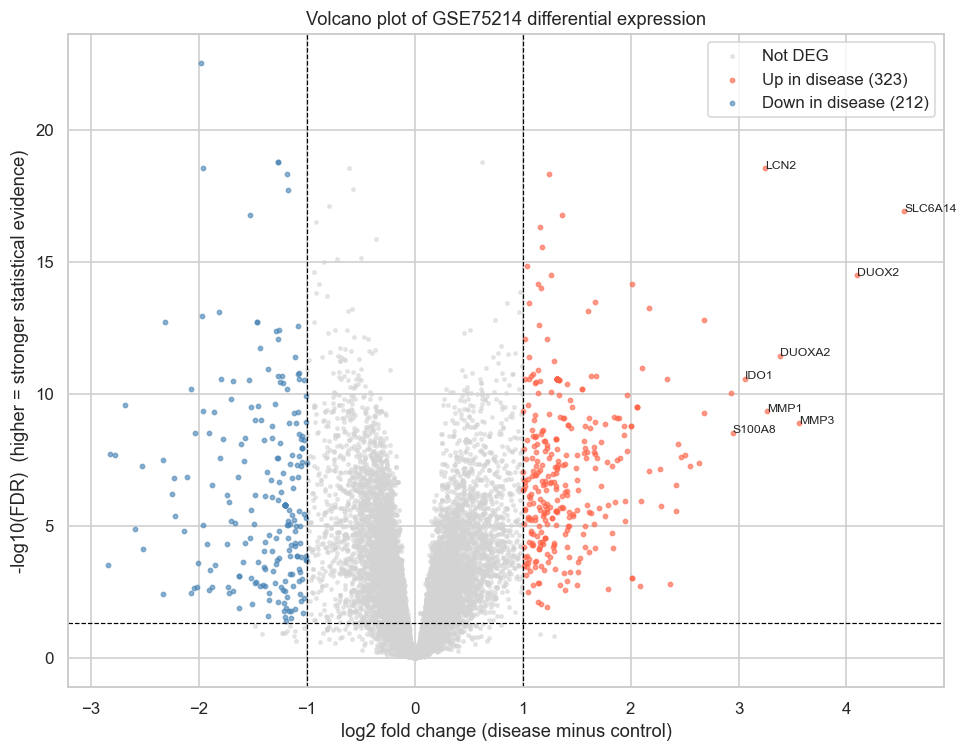

In [7]:
# The volcano plot shows magnitude on the x axis (log2 fold change) against
# significance on the y axis (minus log10 FDR). Genes far up and to the sides are
# both large and reliable, which is what we want in a biomarker.
def volcano(dge_table, fc_cut=1.0, fdr_cut=0.05, path=None):
    """Draw a volcano plot and label a few of the strongest genes."""
    t = dge_table
    neglog = -np.log10(t["FDR"].clip(lower=1e-300))
    up = t["DEG"] & (t["direction"] == "up")
    dn = t["DEG"] & (t["direction"] == "down")
    plt.figure(figsize=(9, 7))
    plt.scatter(t["log2FC"][~t["DEG"]], neglog[~t["DEG"]], s=5, color="lightgrey", alpha=0.5, label="Not DEG")
    plt.scatter(t["log2FC"][up], neglog[up], s=8, color="tomato", alpha=0.6, label=f"Up in disease ({int(up.sum())})")
    plt.scatter(t["log2FC"][dn], neglog[dn], s=8, color="steelblue", alpha=0.6, label=f"Down in disease ({int(dn.sum())})")
    for g in t[t["DEG"]].reindex(t[t["DEG"]]["log2FC"].abs().sort_values(ascending=False).index).head(8).index:
        plt.annotate(g, (t.loc[g, "log2FC"], neglog.loc[g]), fontsize=8)
    plt.axvline(fc_cut, color="black", linestyle="--", linewidth=0.8)
    plt.axvline(-fc_cut, color="black", linestyle="--", linewidth=0.8)
    plt.axhline(-np.log10(fdr_cut), color="black", linestyle="--", linewidth=0.8)
    plt.xlabel("log2 fold change (disease minus control)")
    plt.ylabel("-log10(FDR)  (higher = stronger statistical evidence)")
    plt.title("Volcano plot of GSE75214 differential expression")
    plt.legend()
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=150)
    plt.show()

volcano(dge, path=FIG / "task2_1_volcano.png")


More genes sit on the right, so more strong changes are upregulated. The labelled
names are examples with large logFC and small FDR. We cannot say they are diagnostic tests.
They are candidates to check with feature selection and ROC.


## 7. MA plot


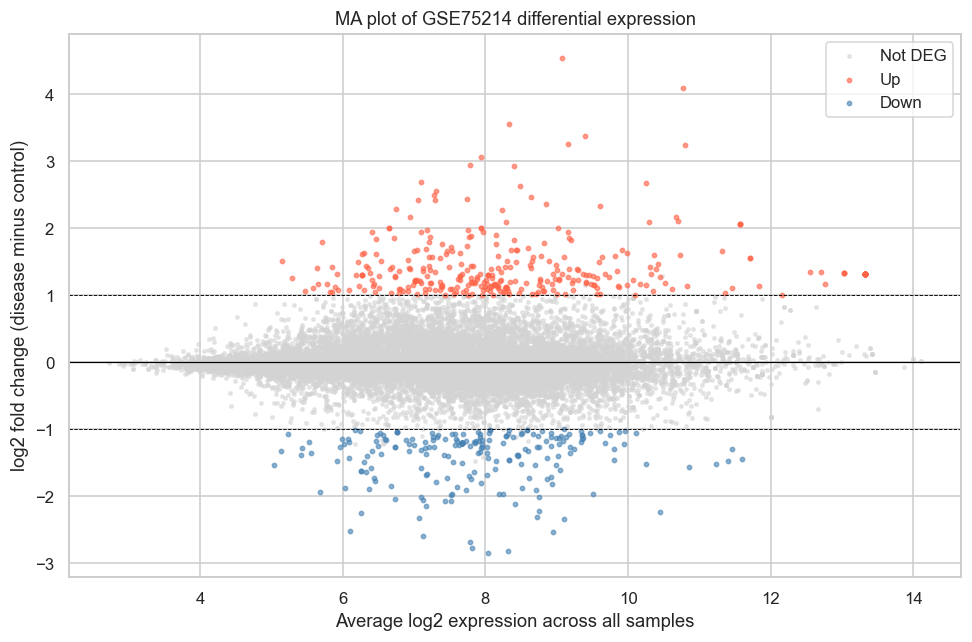

In [8]:
# The MA plot shows the average expression of a gene against its fold change.
# It checks that large fold changes are not only an artefact of low expression genes.
def ma_plot(genes_matrix, dge_table, path=None):
    """Draw an MA plot, average expression against log2 fold change."""
    avg = genes_matrix.mean(axis=0)
    avg = avg.reindex(dge_table.index)
    t = dge_table
    plt.figure(figsize=(9, 6))
    plt.scatter(avg[~t["DEG"]], t["log2FC"][~t["DEG"]], s=5, color="lightgrey", alpha=0.5, label="Not DEG")
    plt.scatter(avg[t["DEG"] & (t["direction"] == "up")], t["log2FC"][t["DEG"] & (t["direction"] == "up")], s=8, color="tomato", alpha=0.6, label="Up")
    plt.scatter(avg[t["DEG"] & (t["direction"] == "down")], t["log2FC"][t["DEG"] & (t["direction"] == "down")], s=8, color="steelblue", alpha=0.6, label="Down")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.axhline(1, color="black", linestyle="--", linewidth=0.6)
    plt.axhline(-1, color="black", linestyle="--", linewidth=0.6)
    plt.xlabel("Average log2 expression across all samples")
    plt.ylabel("log2 fold change (disease minus control)")
    plt.title("MA plot of GSE75214 differential expression")
    plt.legend()
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=150)
    plt.show()

ma_plot(genes, dge, path=FIG / "task2_1_ma.png")

DEGs appear across low and high average expression. This means the signal is
not only noisy low-expression genes. The MA plot does not rank biomarkers by itself.


## 8. Heatmap of the strongest DEGs

Rows are samples (red = disease, blue = control). Columns are the 40 genes with the largest
|logFC|. Clustering groups similar samples and similar genes. Modules are co-expression
blocks, not proof of a pathway.


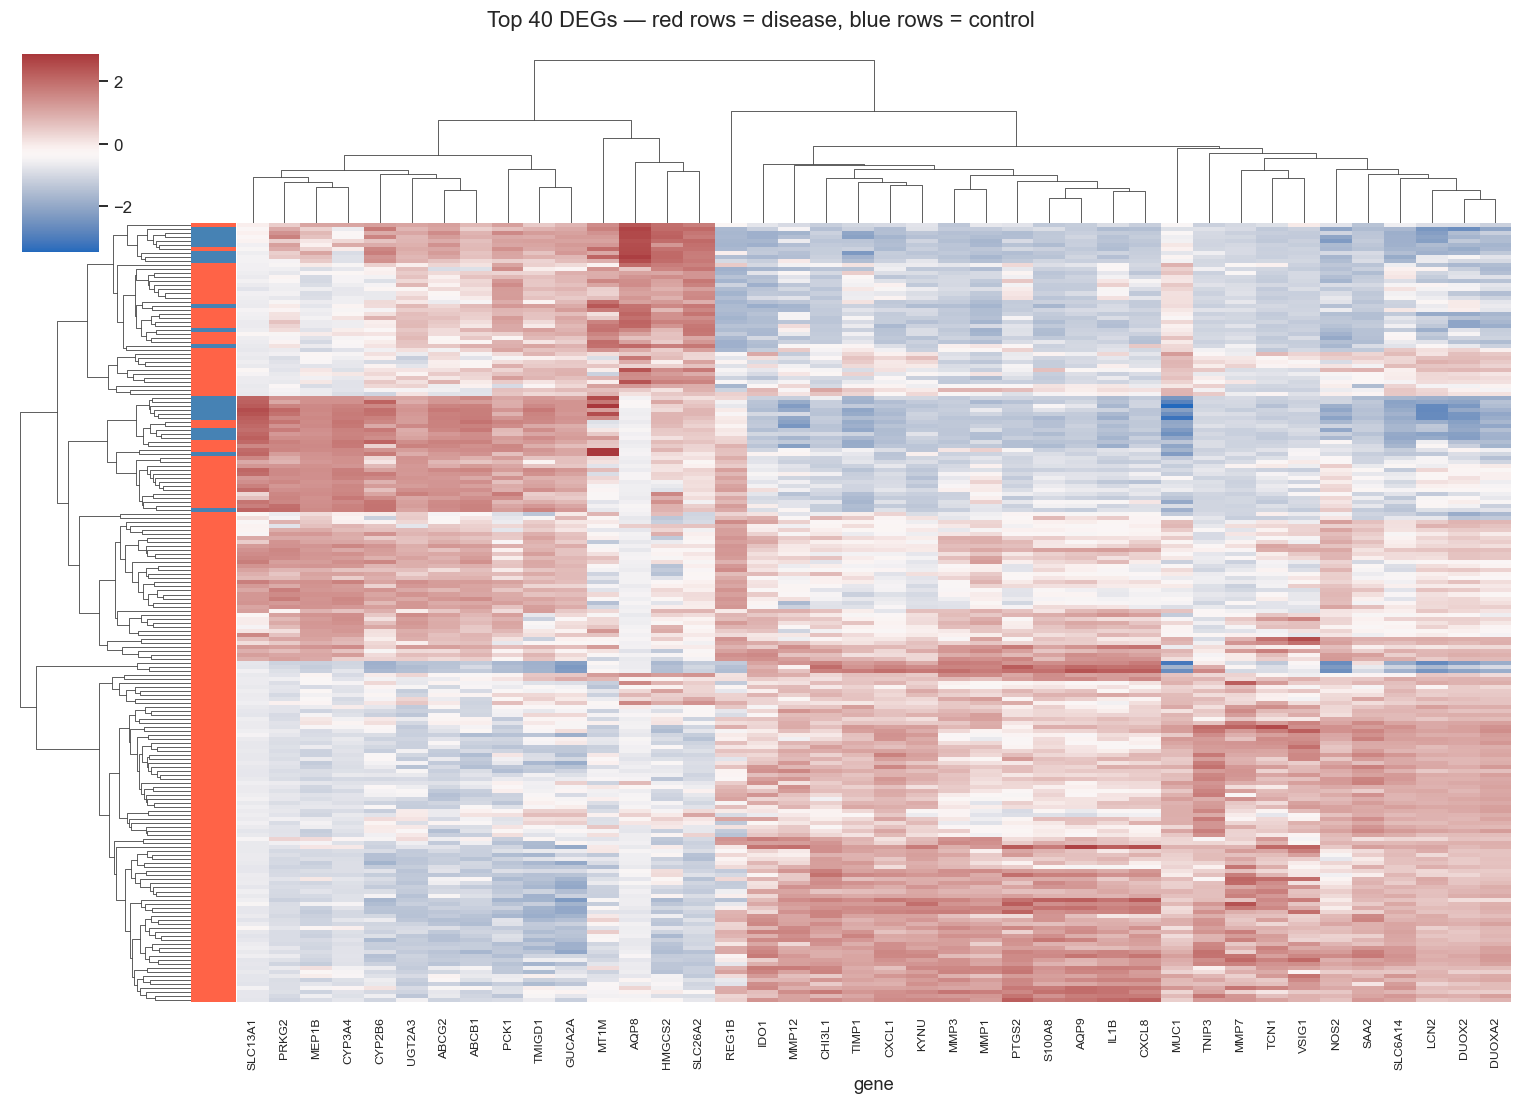

Gene modules in the heatmap (read left → right on the x axis):


,gene,cluster_position,module,log2FC,FDR,direction
0,SLC13A1,1,1,-2.516310,7.772739e-05,down
1,PRKG2,2,1,-2.252457,6.392515e-07,down
2,MEP1B,3,1,-2.841531,2.998035e-04,down
3,CYP3A4,4,1,-2.329615,3.845510e-03,down
4,CYP2B6,5,1,-2.685003,2.695643e-10,down
5,UGT2A3,6,1,-2.590060,1.280849e-05,down
6,ABCG2,7,1,-2.774521,2.028751e-08,down
7,ABCB1,8,1,-2.110422,1.397253e-07,down
8,PCK1,9,1,-2.220152,4.402362e-06,down
9,TMIGD1,10,1,-2.821645,1.931112e-08,down



Module 1 (11 genes): SLC13A1, PRKG2, MEP1B, CYP3A4, CYP2B6, UGT2A3, ABCG2, ABCB1, PCK1, TMIGD1, GUCA2A

Module 2 (4 genes): MT1M, AQP8, HMGCS2, SLC26A2

Module 3 (24 genes): IDO1, MMP12, CHI3L1, TIMP1, CXCL1, KYNU, MMP3, MMP1, PTGS2, S100A8, AQP9, IL1B, CXCL8, MUC1, TNIP3, MMP7, TCN1, VSIG1, NOS2, SAA2, SLC6A14, LCN2, DUOX2, DUOXA2

Module 4 (1 genes): REG1B


In [9]:
# Clustered heatmap of the 40 strongest DEGs (samples as rows).
# After clustering we cut the *gene* dendrogram into modules so you can read which
# genes travel together (the red boxes you draw by hand in other assignments).
from scipy.cluster.hierarchy import fcluster

N_HEAT = 40
N_MODULES = 4
top_heat = (
    dge[dge["DEG"]]
    .reindex(dge[dge["DEG"]]["log2FC"].abs().sort_values(ascending=False).index)
    .head(N_HEAT)
)
top40 = top_heat.index.tolist()
heat = genes[top40]
row_colors = ["tomato" if v == 1 else "steelblue" for v in target]

cg = sns.clustermap(
    heat, cmap="vlag", z_score=1, figsize=(14, 10),
    row_colors=row_colors, col_cluster=True, row_cluster=True,
    xticklabels=True, yticklabels=False, dendrogram_ratio=(0.12, 0.18),
)
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
cg.fig.suptitle("Top 40 DEGs — red rows = disease, blue rows = control", y=1.02)
cg.savefig(FIG / "task2_1_heatmap.png", dpi=150)
plt.show()

# Gene order after clustering + module id (1..N_MODULES)
order = cg.dendrogram_col.reordered_ind
gene_order = [heat.columns[i] for i in order]
modules = fcluster(cg.dendrogram_col.linkage, t=N_MODULES, criterion="maxclust")
mod_by_orig = {heat.columns[i]: int(modules[i]) for i in range(len(heat.columns))}
cluster_map = pd.DataFrame({
    "gene": gene_order,
    "cluster_position": range(1, len(gene_order) + 1),
    "module": [mod_by_orig[g] for g in gene_order],
    "log2FC": [float(dge.loc[g, "log2FC"]) for g in gene_order],
    "FDR": [float(dge.loc[g, "FDR"]) for g in gene_order],
    "direction": [dge.loc[g, "direction"] for g in gene_order],
})
print("Gene modules in the heatmap (read left → right on the x axis):")
display(cluster_map)
for m, sub in cluster_map.groupby("module"):
    print(f"\nModule {m} ({len(sub)} genes): {', '.join(sub['gene'].tolist())}")
cluster_map.to_csv(OUT / "task2_1_heatmap_gene_modules.csv", index=False)


Disease and control rows often form two blocks on these 40 genes. That shows
the top DEGs can separate groups in this dataset. It does not prove a clinical signature.
The module table lists which genes travel together on the x-axis.


## 9. Save the results for the next notebooks

Tables below are the same data saved to `04_Analysis/*.csv`. Expression matrices are saved but not printed (too many columns).


In [10]:
from task2_1_lib import save_and_show

# Save tables AND show analytical results in the notebook for review.
dge_out = dge.copy()
print(f"Full gene-level DGE table: {dge_out.shape[0]:,} genes × {dge_out.shape[1]} columns (saved, not printed)")
dge_out.to_csv(OUT / "dge_table_2_1.csv")
print(f"Saved: {OUT / 'dge_table_2_1.csv'}")

deg_genes = dge[dge["DEG"]].index.tolist()
deg_matrix = genes[deg_genes].copy()
deg_matrix.insert(0, "target", target)
print(
    f"DEG expression matrix (saved, not printed): "
    f"{deg_matrix.shape[0]} samples × {deg_matrix.shape[1] - 1} genes + target column"
)
deg_matrix.to_csv(OUT / "deg_matrix_2_1.csv", index=False)
print(f"Saved: {OUT / 'deg_matrix_2_1.csv'}")

deg_table = dge[dge["DEG"]][["log2FC", "FDR", "direction"]].copy()
deg_table = deg_table.sort_values("log2FC", ascending=False)
up_table = up[cols].copy()
down_table = down[cols].copy()

print(f"\nSummary: {len(deg_table)} DEGs ({len(up_table)} up, {len(down_table)} down)")

save_and_show(deg_table, OUT / "deg_list_2_1.csv", title="All DEGs (unified list):")
save_and_show(up_table, OUT / "deg_up_2_1.csv", title="All upregulated DEGs (higher in disease):")
save_and_show(down_table, OUT / "deg_down_2_1.csv", title="All downregulated DEGs (lower in disease):")


Full gene-level DGE table: 21,147 genes × 7 columns (saved, not printed)
Saved: ..\04_Analysis\dge_table_2_1.csv
DEG expression matrix (saved, not printed): 194 samples × 535 genes + target column


Saved: ..\04_Analysis\deg_matrix_2_1.csv

Summary: 535 DEGs (323 up, 212 down)
All DEGs (unified list):


,log2FC,FDR,direction
gene,,,
SLC6A14,4.5331,0.0000,up
DUOX2,4.0973,0.0000,up
MMP3,3.5576,0.0000,up
DUOXA2,3.3827,0.0000,up
MMP1,3.2628,0.0000,up
...,...,...,...
UGT2A3,-2.5901,0.0000,down
CYP2B6,-2.6850,0.0000,down
ABCG2,-2.7745,0.0000,down


Saved: ..\04_Analysis\deg_list_2_1.csv
All upregulated DEGs (higher in disease):


,log2FC,FDR,AveExpr
gene,,,
SLC6A14,4.5331,0.0,9.0684
DUOX2,4.0973,0.0,10.7740
MMP3,3.5576,0.0,8.3287
DUOXA2,3.3827,0.0,9.4023
MMP1,3.2628,0.0,9.1635
...,...,...,...
LYZ,1.0086,0.0,12.1548
IGFBP7,1.0074,0.0,10.0983
ASPHD2,1.0054,0.0,7.4334


Saved: ..\04_Analysis\deg_up_2_1.csv
All downregulated DEGs (lower in disease):


,log2FC,FDR,AveExpr
gene,,,
MEP1B,-2.8415,0.0003,8.0363
TMIGD1,-2.8216,0.0000,8.3101
ABCG2,-2.7745,0.0000,7.8068
CYP2B6,-2.6850,0.0000,7.7820
UGT2A3,-2.5901,0.0000,7.1248
...,...,...,...
SUGCT,-1.0120,0.0000,6.1689
LGALS2,-1.0054,0.0001,8.0631
ALDOC,-1.0052,0.0000,8.0578


Saved: ..\04_Analysis\deg_down_2_1.csv


## Limitations

GSE75214 has only 22 controls. DGE, feature selection and evaluation use the same GEO
series, so later AUC values can look too good. Survival analysis is not possible here.
We treat DEGs as candidate genes, not confirmed clinical biomarkers.

## Notebook 1 summary

We mapped probes to genes, ran limma-style DGE, and called 535 DEGs (323 up, 212 down).
Next, Notebook 2 asks a different question: which of these genes help a classifier.

Oral-defense questions are consolidated in `2_0_final_overview.ipynb` (section **Oral defense**).
